# Loading Dataset

In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chetanmittal033/road-accident-dataset/sample_submission.csv
/kaggle/input/datasets/chetanmittal033/road-accident-dataset/train.csv
/kaggle/input/datasets/chetanmittal033/road-accident-dataset/test.csv


In [14]:
df = pd.read_csv('/kaggle/input/datasets/chetanmittal033/road-accident-dataset/train.csv')
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


# EDA

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


## For Predicting accident_risk there are:-

4 categorical coloumns = road_type, lightning, weather, time_of_day

4 boolean coloumns = road_signs_present, public_road, holiday, school_season

4 numeric coloumns = num_lanes, curvature, speed_limit, num_reported_accidents

In [16]:
print(df.isna().sum())
print(df.shape)

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64
(517754, 14)


no null values found

dataset has 517754 rows and 14 coloumns

### since accident_risk is float type we plot a density plot to assess it's range

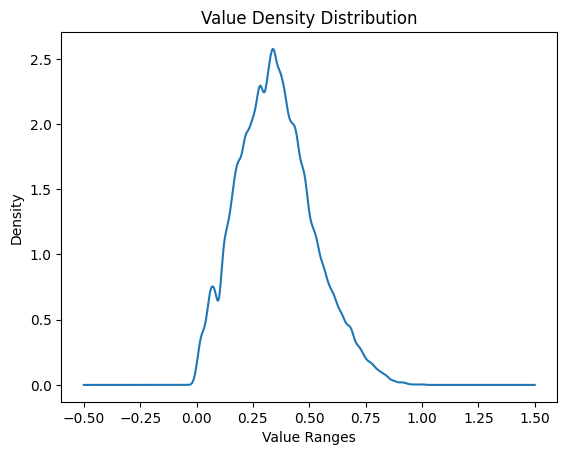

In [17]:
import matplotlib.pyplot as plt
df['accident_risk'].plot(kind='kde')
plt.title('Value Density Distribution')
plt.xlabel('Value Ranges')
plt.show()

it is conclusive that regression is best for predicting these numeric values in range between 0 and 1

# Main pipleline for regression

## imports

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']

num_cols = [
    "num_lanes",
    "curvature",
    "speed_limit",
    "road_signs_present",
    "public_road",
    "holiday",
    "school_season",
    "num_reported_accidents"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

use one hot encoding to encode categorical values and passthrough bools and numerics

## training a baseline model

In [20]:
model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("regressor",RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1))
    ]
)

X = df.drop(columns=["id", "accident_risk"])
y = df["accident_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['road_type', 'lighting',
                                                   'weather', 'time_of_day']),
                                                 ('num', 'passthrough',
                                                  ['num_lanes', 'curvature',
                                                   'speed_limit',
                                                   'road_signs_present',
                                                   'public_road', 'holiday',
                                                   'school_season',
                                                   'num_reported_accidents'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

# Predictions and Model analysis

In [21]:
preds = model.predict(X_test)
print("mae:", mean_absolute_error(y_test,preds))
print("rmse:", np.sqrt(mean_squared_error(y_test,preds)))
print("r2:", r2_score(y_test,preds))

mae: 0.04602901997003784
rmse: 0.05930308859663709
r2: 0.8726339426918339


Baseline model is decent therefore we now convert numerical outputs to labeled in order to help understand severity better


In [22]:
def risk_category(x):
    if x < 0.25:
        return "Low"
    elif x < 0.50:
        return "Medium"
    else:
        return "High"

y_pred = model.predict(X_test)
predicted_risk_level = [risk_category(x) for x in y_pred]
actual_risk_level = [risk_category(x) for x in y_test]

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(actual_risk_level, predicted_risk_level))
print(confusion_matrix(actual_risk_level, predicted_risk_level))

              precision    recall  f1-score   support

        High       0.85      0.79      0.82     19214
         Low       0.84      0.81      0.82     28767
      Medium       0.83      0.87      0.85     55570

    accuracy                           0.84    103551
   macro avg       0.84      0.82      0.83    103551
weighted avg       0.84      0.84      0.84    103551

[[15094     5  4115]
 [    1 23218  5548]
 [ 2664  4392 48514]]


# Training more Regression Models

adding Linear Regression, Ridge Regression, Decision Trees, Gradient Boost and Extra Trees regressor 

In [23]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

creating a similar pipeline to train all the models

In [24]:
for name, regressor in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(name)
    print("mae:", mae)
    print("rmse:", rmse)
    print("r2:", r2)

Linear Regression
mae: 0.05831216757325721
rmse: 0.07353086258983137
r2: 0.8041884067087808
Ridge Regression
mae: 0.058312140178481145
rmse: 0.0735308547723908
r2: 0.8041884483442344
Decision Tree
mae: 0.06411715000337996
rmse: 0.08324724833560034
r2: 0.7490201506965752
Random Forest
mae: 0.046029019970037846
rmse: 0.05930308859663709
r2: 0.8726339426918339
Extra Trees
mae: 0.04839341097623393
rmse: 0.0624353157434102
r2: 0.858824379742013
Gradient Boosting
mae: 0.044364041117174395
rmse: 0.05702040135970744
r2: 0.8822503514181602


Gradient boosting performs best with avg risk prediction error of 0.044. it means the model is off by 4.4 percentage on average 

Now we use hyper parameter tuning to improve the model

## Hyper Parameter Tuning

In [25]:
from sklearn.model_selection import RandomizedSearchCV
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])
param_grid = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__max_depth": [2, 3, 4, 5],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__subsample": [0.7, 0.8, 0.9, 1.0]
}
search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_grid,
    n_iter=3,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END regressor__learning_rate=0.03, regressor__max_depth=3, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=500, regressor__subsample=0.7; total time= 3.9min
[CV] END regressor__learning_rate=0.05, regressor__max_depth=2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=500, regressor__subsample=0.9; total time= 3.3min
[CV] END regressor__learning_rate=0.03, regressor__max_depth=3, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=500, regressor__subsample=0.7; total time= 4.0min
[CV] END regressor__learning_rate=0.03, regressor__max_depth=5, regressor__min_samples_leaf=4, regressor__min_samples_split=5, regressor__n_estimators=300, regressor__subsample=0.9; total time= 4.2min
[CV] END regressor__learning_rate=0.03, regressor__max_depth=3, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regres

In [26]:
best_gb_model = search.best_estimator_

y_pred = best_gb_model.predict(X_test)

print("Tuned Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Tuned Gradient Boosting
MAE: 0.04384733813437473
RMSE: 0.05643635989447577
R2: 0.8846501408897434


No major increase but it was expected since iter was limited to 3 

# Saving the model

In [27]:
import joblib
joblib.dump(best_gb_model, "accident_risk_model.pkl")

['accident_risk_model.pkl']

## how to load the model and evalutate it

In [30]:
loaded_model = joblib.load("/kaggle/working/accident_risk_model.pkl")
preds = loaded_model.predict(X_test)

In [42]:
predicted_risk_level = [risk_category(x) for x in preds]
actual_risk_level = [risk_category(x) for x in y_test]
ordered_labels = ["Low", "Medium", "High"] 

## Plotting confusion matrix for evaluating newly loaded best model

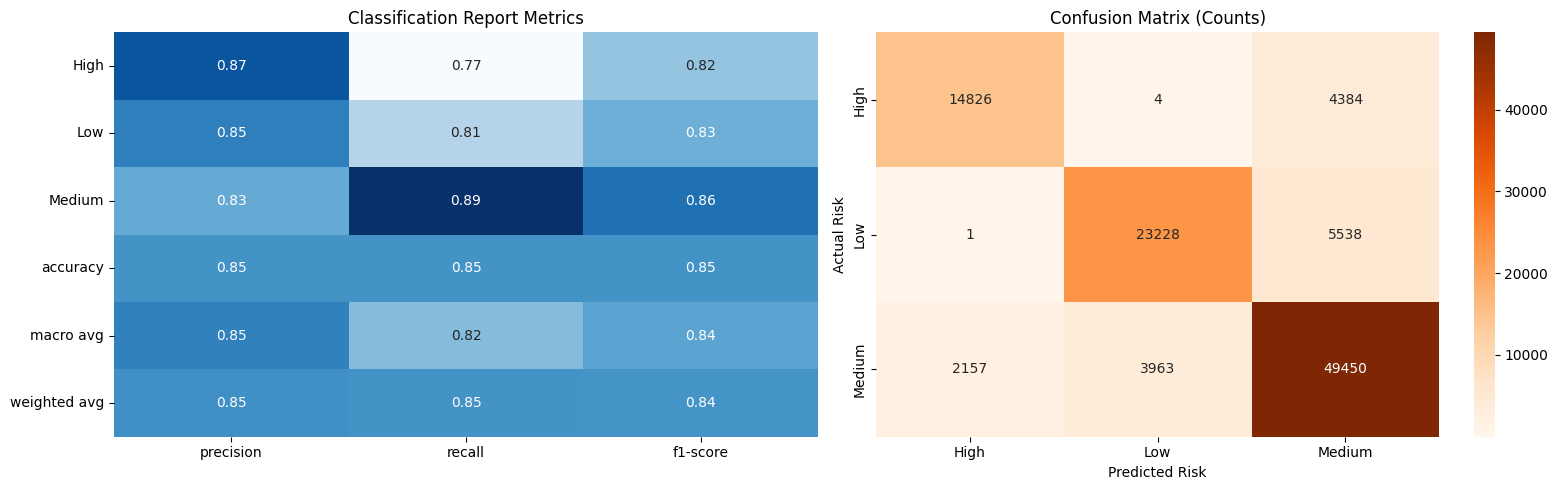

              precision    recall  f1-score   support

         Low       0.85      0.81      0.83     28767
      Medium       0.83      0.89      0.86     55570
        High       0.87      0.77      0.82     19214

    accuracy                           0.85    103551
   macro avg       0.85      0.82      0.84    103551
weighted avg       0.85      0.85      0.84    103551



In [43]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
report_dict = classification_report(actual_risk_level, predicted_risk_level, output_dict=True)
df_report = pd.DataFrame(report_dict).iloc[:-1, :].T

sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f", ax=ax[0], cbar=False)
ax[0].set_title("Classification Report Metrics")
cm = confusion_matrix(actual_risk_level, predicted_risk_level)
labels = sorted(list(set(actual_risk_level)))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt="d", ax=ax[1],
            xticklabels=labels, yticklabels=labels)
ax[1].set_title("Confusion Matrix (Counts)")
ax[1].set_xlabel("Predicted Risk")
ax[1].set_ylabel("Actual Risk")
plt.tight_layout()
plt.show()

print(classification_report(actual_risk_level, predicted_risk_level, labels=ordered_labels))


## Lastly testing it on a new test set instead of the old train set split

In [44]:
test_df = pd.read_csv("/kaggle/input/datasets/chetanmittal033/road-accident-dataset/test.csv")

test_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [45]:
test_df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents'],
      dtype='object')

since there is no accident_risk coloumn we can only generate predictions and cannot test the model

In [46]:
X_test_new = test_df.drop(columns=["id"])

y_pred_new = model.predict(X_test_new)

predictions_df = pd.DataFrame({
    "id": test_df["id"],
    "predicted_accident_risk": y_pred_new
})

predictions_df.head()

,id,predicted_accident_risk
0,517754,0.292996
1,517755,0.126674
2,517756,0.188771
3,517757,0.335405
4,517758,0.408987


saving the predictions

In [50]:
predictions_df.to_csv("/kaggle/working/test_predictions.csv", index=False)

same function as before to create proxy values for severity for better understanding of data

In [48]:
def risk_category(x):
    if x < 0.25:
        return "Low"
    elif x < 0.50:
        return "Medium"
    else:
        return "High"

predictions_df["risk_category"] = predictions_df["predicted_accident_risk"].apply(risk_category)

predictions_df.head()

,id,predicted_accident_risk,risk_category
0,517754,0.292996,Medium
1,517755,0.126674,Low
2,517756,0.188771,Low
3,517757,0.335405,Medium
4,517758,0.408987,Medium
